
Dataset Information:
   attendance  internal_marks  assignments  study_hours  previous_semester  \
0          93              93           42          5.5                 90   
1          83              83           57          4.2                 78   
2          69              36           64          4.8                 77   
3          97              36           81          7.6                 73   
4          62              62           70          3.7                 77   

   final_score  
0    94.192453  
1    82.585612  
2    73.235494  
3    83.176477  
4    73.549020  

Missing values:
attendance           0
internal_marks       0
assignments          0
study_hours          0
previous_semester    0
final_score          0
dtype: int64

Linear Regression
MAE  : 2.96
RMSE : 3.54
R2   : 0.86

Random Forest
MAE  : 3.56
RMSE : 4.33
R2   : 0.79


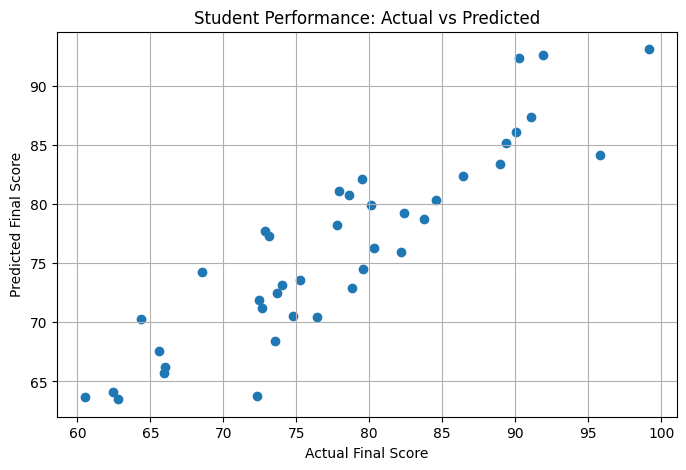

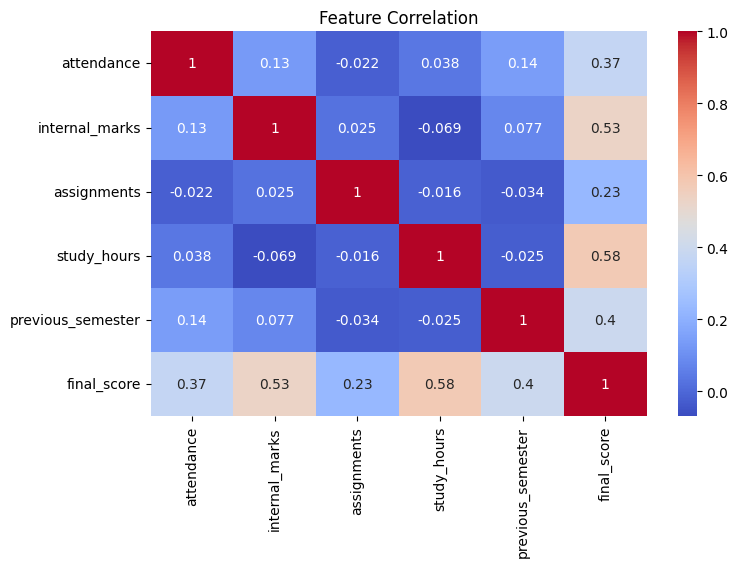


Model saved as: student_performance_model.pkl

New Student Prediction
Predicted Final Score: 87.17
Performance Category: Excellent


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Create sample dataset
# -----------------------------
np.random.seed(42)

n = 200
data = pd.DataFrame({
    "attendance": np.random.randint(55, 101, n),
    "internal_marks": np.random.randint(35, 96, n),
    "assignments": np.random.randint(40, 101, n),
    "study_hours": np.round(np.random.uniform(1, 8, n), 1),
    "previous_semester": np.random.randint(40, 96, n)
})

# Target: final academic score
data["final_score"] = (
    0.20 * data["attendance"]
    + 0.30 * data["internal_marks"]
    + 0.15 * data["assignments"]
    + 3.0 * data["study_hours"]
    + 0.25 * data["previous_semester"]
    + np.random.normal(0, 3, n)
)

data["final_score"] = data["final_score"].clip(0, 100)

# Save dataset
data.to_csv("student_performance_dataset.csv", index=False)

# -----------------------------
# 2. Data preprocessing
# -----------------------------
print("\nDataset Information:")
print(data.head())
print("\nMissing values:")
print(data.isnull().sum())

X = data[
    ["attendance", "internal_marks", "assignments",
     "study_hours", "previous_semester"]
]
y = data["final_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# -----------------------------
# 3. Model 1 - Linear Regression
# -----------------------------
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

# -----------------------------
# 4. Model 2 - Random Forest
# -----------------------------
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# -----------------------------
# 5. Evaluation function
# -----------------------------
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.2f}")

evaluate_model("Linear Regression", y_test, linear_pred)
evaluate_model("Random Forest", y_test, rf_pred)

# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Student Performance: Actual vs Predicted")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# -----------------------------
# 7. Save trained model
# -----------------------------
joblib.dump(rf_model, "student_performance_model.pkl")
print("\nModel saved as: student_performance_model.pkl")

# -----------------------------
# 8. Predict a new student
# -----------------------------
new_student = pd.DataFrame({
    "attendance": [90],
    "internal_marks": [82],
    "assignments": [88],
    "study_hours": [5],
    "previous_semester": [80]
})

prediction = rf_model.predict(new_student)[0]

print("\nNew Student Prediction")
print(f"Predicted Final Score: {prediction:.2f}")

if prediction >= 75:
    performance = "Excellent"
elif prediction >= 60:
    performance = "Good"
elif prediction >= 50:
    performance = "Average"
else:
    performance = "Needs Improvement"

print(f"Performance Category: {performance}")



Dataset Information:
   area  bedrooms location  bathrooms  parking  age       price
0  1460         2    Delhi          3        0   11  181.062414
1  1894         2    Delhi          4        1   11  196.788653
2  1730         3  Roorkee          1        1    3  139.264517
3  1695         4  Roorkee          3        1   15  163.671113
4  2238         2  Roorkee          1        2    3  174.356924

Missing values:
area         0
bedrooms     0
location     0
bathrooms    0
parking      0
age          0
price        0
dtype: int64

Linear Regression
MAE  : 6.04 lakh
RMSE : 7.33 lakh
R2   : 0.98

Random Forest
MAE  : 8.41 lakh
RMSE : 11.08 lakh
R2   : 0.95


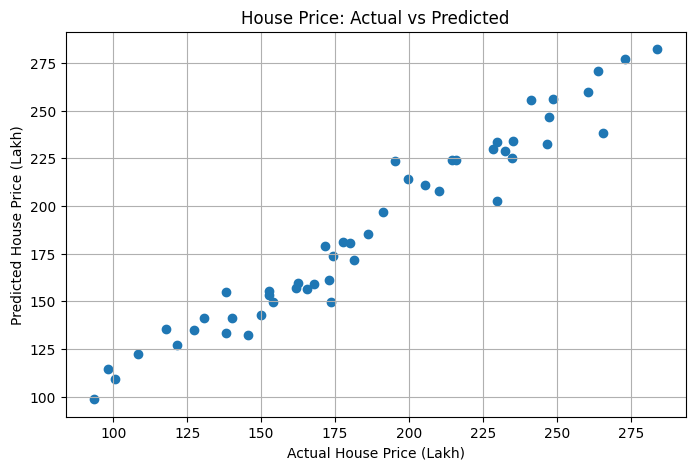

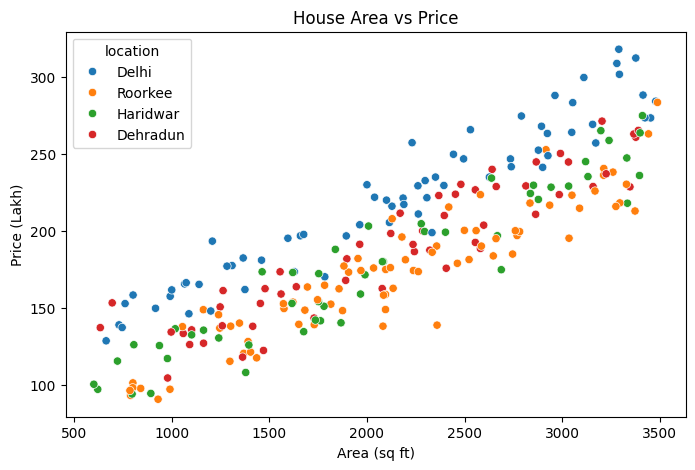

In [ ]:
# PROJECT 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Create sample dataset
# -----------------------------
np.random.seed(42)

n = 250

locations = ["Roorkee", "Haridwar", "Dehradun", "Delhi"]

data = pd.DataFrame({
    "area": np.random.randint(600, 3500, n),
    "bedrooms": np.random.randint(1, 6, n),
    "location": np.random.choice(locations, n),
    "bathrooms": np.random.randint(1, 5, n),
    "parking": np.random.randint(0, 3, n),
    "age": np.random.randint(0, 31, n)
})

location_value = {
    "Roorkee": 5,
    "Haridwar": 7,
    "Dehradun": 9,
    "Delhi": 15
}

data["location_value"] = data["location"].map(location_value)

# Target price in lakh
data["price"] = (
    data["area"] * 0.055
    + data["bedrooms"] * 8
    + data["bathrooms"] * 5
    + data["parking"] * 3
    - data["age"] * 0.7
    + data["location_value"] * 5
    + np.random.normal(0, 8, n)
)

data["price"] = data["price"].clip(20, None)
data.drop(columns=["location_value"], inplace=True)

# Save dataset
data.to_csv("house_price_dataset.csv", index=False)

# -----------------------------
# 2. Data preprocessing
# -----------------------------
print("\nDataset Information:")
print(data.head())

print("\nMissing values:")
print(data.isnull().sum())

X = data[
    ["area", "bedrooms", "location",
     "bathrooms", "parking", "age"]
]
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_features = ["area", "bedrooms", "bathrooms", "parking", "age"]
categorical_features = ["location"]

preprocessor = ColumnTransformer([
    (
        "numeric",
        StandardScaler(),
        numeric_features
    ),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    )
])

# -----------------------------
# 3. Model 1 - Linear Regression
# -----------------------------
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

# -----------------------------
# 4. Model 2 - Random Forest
# -----------------------------
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=150,
            random_state=42
        )
    )
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# -----------------------------
# 5. Evaluation
# -----------------------------
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f} lakh")
    print(f"RMSE : {rmse:.2f} lakh")
    print(f"R2   : {r2:.2f}")

evaluate_model("Linear Regression", y_test, linear_pred)
evaluate_model("Random Forest", y_test, rf_pred)

# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual House Price (Lakh)")
plt.ylabel("Predicted House Price (Lakh)")
plt.title("House Price: Actual vs Predicted")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=data,
    x="area",
    y="price",
    hue="location"
)
plt.title("House Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (Lakh)")
plt.show()

# -----------------------------
# 7. Save trained model
# -----------------------------
joblib.dump(rf_model, "house_price_model.pkl")
print("\nModel saved as: house_price_model.pkl")

# -----------------------------
# 8. Predict a new house
# -----------------------------
new_house = pd.DataFrame({
    "area": [1800],
    "bedrooms": [3],
    "location": ["Roorkee"],
    "bathrooms": [2],
    "parking": [1],
    "age": [5]
})

prediction = rf_model.predict(new_house)[0]

print("\nNew House Prediction")
print(f"Predicted House Price: {prediction:.2f} lakh")

